In [1]:
%pip install qiskit
%pip install qiskit-aer
%pip install pylatexenc
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


# Redundancy & Stabilizer Measurement

Qubits are fragile and cannot be cloned (no-cloning theorem).  
To protect quantum information, we use entanglement for redundancy.

Two-qubit encoding:
The logical qubit is encoded across two physical qubits using a CNOT gate (control = qubit 0, target = qubit 1).

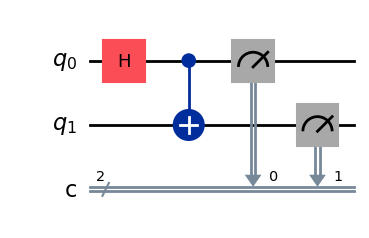

In [41]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(2,2)
qc.h(0)  
qc.cx(0,1)
qc.measure([0,1],[0,1])
display(qc.draw(output='mpl'))

## Encoding Qubits

The **3-bit repetition code** is a classical error-correcting code, but we can consider what happens if we try to use it to protect **qubits** against errors. As we'll see, it's not a very impressive quantum error-correcting code, because it actually makes some errors more likely. It is, however, the first step toward the **Shor code**, and will serve us well from a pedagogical viewpoint.

To be clear, when we refer to the **3-bit repetition code** being used for qubits, we have in mind an **encoding of a qubit** where standard basis states are repeated three times, so that a single-qubit state vector is encoded as follows:

$$
\alpha |0\rangle + \beta |1\rangle
;\mapsto;
\alpha |000\rangle + \beta |111\rangle
$$

This encoding is easily implemented by the following **quantum circuit**, which makes use of:

* Two initialized workspace qubits
* Two controlled-NOT (CNOT) gates

The circuit copies the computational basis information of the original qubit into two additional qubits, creating the encoded three-qubit state.


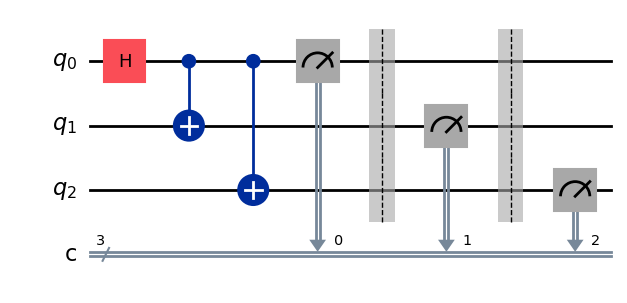

In [42]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

#Prepare of qubit
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

# Measure qubits
qc.measure(0,0)
qc.barrier()
qc.measure(1,1)
qc.barrier()
qc.measure(2,2)

#circuit
qc.draw('mpl')
display(qc.draw(output='mpl'))

Notice, in particular, that this encoding is **not** the same as repeating the quantum state three times, as in a given qubit state vector being encoded as

$$
|\psi\rangle \mapsto |\psi\rangle |\psi\rangle |\psi\rangle .
$$

Such an encoding **cannot be implemented** for an unknown quantum state $|\psi\rangle$ due to the **no-cloning theorem**.


## Bit-Flip Errors

Notice, in particular, that this encoding is **not** the same as repeating the quantum state three times. That is, it is not

$$
|\psi\rangle \mapsto |\psi\rangle |\psi\rangle |\psi\rangle
$$

for an unknown quantum state $|\psi\rangle$. Such an encoding cannot be implemented due to the **no-cloning theorem**.

---

## Bit-Flip Errors

Now suppose that an error takes place after the encoding has been performed. Specifically, let's suppose that an **X gate**, or in other words a **bit-flip**, occurs on one of the qubits.

For instance, if the **middle qubit** experiences a bit-flip, the state of the three qubits is transformed into:

$$
\alpha |010\rangle + \beta |101\rangle
$$

Of course, this isn't the only sort of error that could occur — and it's also reasonable to question the assumption that an error takes the form of a perfect, unitary operation. We'll return to these issues in the last section of the lesson, and for now we can view an error of this form as just one possible type of error (albeit a fundamentally important one).

We can see clearly from the mathematical expression above that the **middle bit** is the one that's different inside each ket. But suppose that we had the three qubits in our possession and didn't know their state.

If we suspected that a bit-flip may have occurred, one option would be to perform a **standard basis measurement**, which, in this case, would cause us to see either:

$$
010 \quad \text{or} \quad 101
$$

with probabilities $|\alpha|^2$ and $|\beta|^2$, respectively. In either case, our conclusion would be that the **middle bit flipped** — but, unfortunately, we would lose the original quantum state:

$$
\alpha |0\rangle + \beta |1\rangle
$$

This is the state we're trying to protect, so measuring in the standard basis is an **unsatisfactory option**.


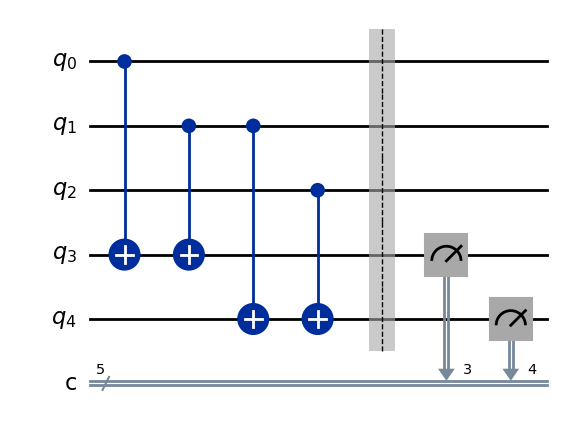

In [43]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

# Syndrome measurement Z1Z2 and Z2Z3 
qc.cx(0,3)
qc.cx(1,3) 
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3)
qc.measure(4,4) 

#circuit
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

Under the assumption that at most one bit flipped, one can easily deduce from the measurement outcomes the location of the bit-flip (or the absence of one). In particular, as the following four circuit diagrams illustrate, the measurement outcome 00 indicates that no bit-flip occurred, while the three other possibilities indicate which qubit experienced a bit-flip.

Raw Counts: {'00111': 509, '00000': 515}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 11 -> Syndrome Eigenvalues: [-1, -1], Count: 509
Bits: 00 -> Syndrome Eigenvalues: [1, 1], Count: 515


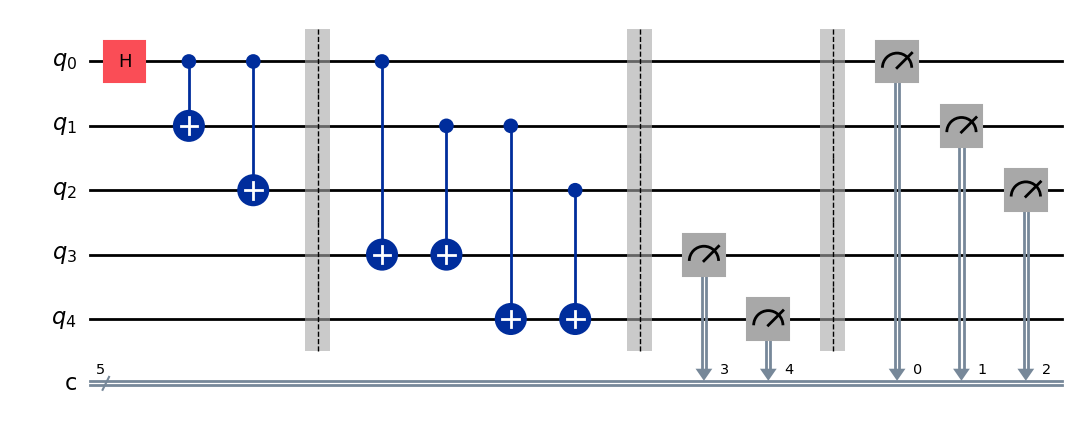

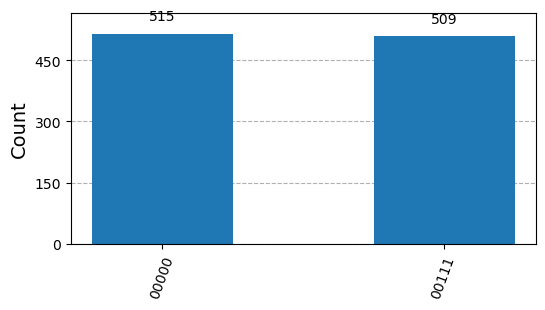

In [44]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode qubit
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.barrier()

#Syndrome measurement
qc.cx(0,3)
qc.cx(1,3)
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3) 
qc.measure(4,4) 
#Measure  qubits 
qc.barrier()
qc.measure(0,0)
qc.measure(1,1)
qc.measure(2,2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Raw Counts: {'01001': 512, '01110': 512}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 01 -> Syndrome Eigenvalues: [1, -1], Count: 512
Bits: 10 -> Syndrome Eigenvalues: [-1, 1], Count: 512


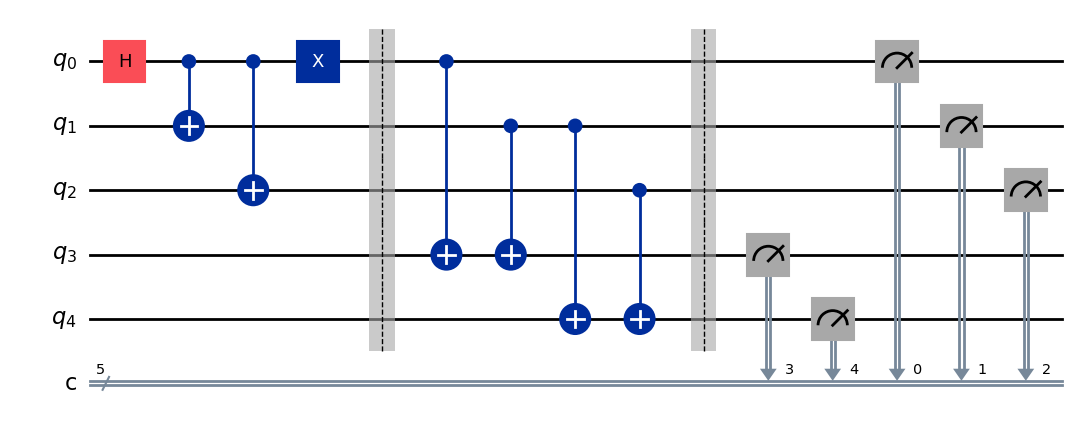

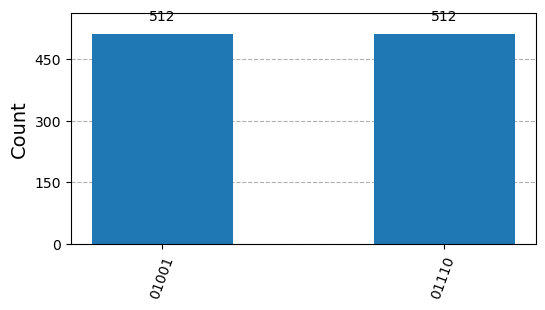

In [45]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc.reset(0)
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.x(0)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0,3)
qc.cx(1,3) 
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3)
qc.measure(4,4) 

#Measure data qubits
qc.measure(0,0)
qc.measure(1,1)
qc.measure(2,2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Counts: {'11101': 516, '11010': 508}


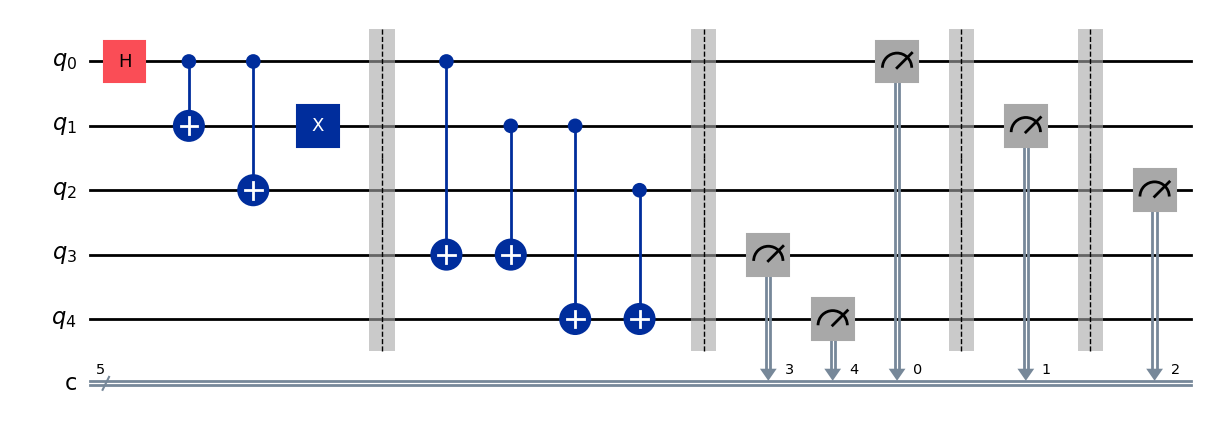


Syndrome Eigenvalues:
Bits: 01 -> Syndrome Eigenvalues: [1, -1]
Bits: 10 -> Syndrome Eigenvalues: [-1, 1]


In [46]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

# Step 1: Encode logical qubit
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.x(1)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0,3)
qc.cx(1,3) 
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3)
qc.measure(4,4) 

#Measure data qubits
qc.measure(0,0)
qc.barrier()
qc.measure(1,1)
qc.barrier()
qc.measure(2,2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

# Get counts
counts = result.get_counts()  # <-- this was missing
print("Counts:", counts)

#Circuit diagram
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

# Convert ancilla bits to syndrome eigenvalues
print("\nSyndrome Eigenvalues:")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  # last two bits are ancillas
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}")

Counts: {'10100': 527, '10011': 497}


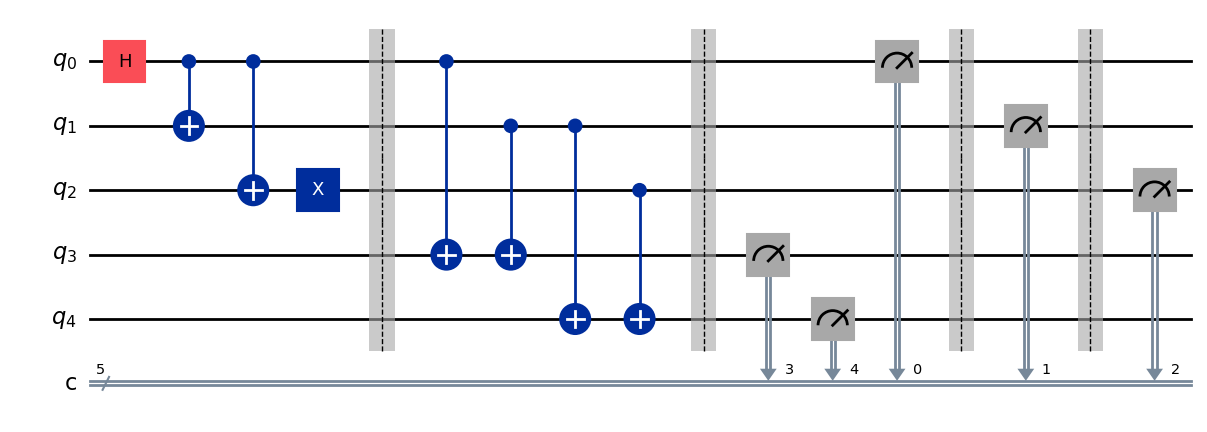


Syndrome Eigenvalues:
Bits: 00 -> Syndrome Eigenvalues: [1, 1]
Bits: 11 -> Syndrome Eigenvalues: [-1, -1]


In [47]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)
qc.cx(0,1)
qc.cx(0,2)
qc.x(2)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0,3)
qc.cx(1,3) 
qc.cx(1,4)
qc.cx(2,4)
qc.barrier()
qc.measure(3,3)
qc.measure(4,4) 

#Measure data qubits
qc.measure(0,0)
qc.barrier()
qc.measure(1,1)
qc.barrier()
qc.measure(2,2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

# Get counts
counts = result.get_counts()  # <-- this was missing
print("Counts:", counts)

# Step 6: Circuit diagram
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

# Step 7: Convert ancilla bits to syndrome eigenvalues
print("\nSyndrome Eigenvalues:")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  # last two bits are ancillas
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}")

Raw Counts: {'01111': 482, '01000': 542}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 11 -> Syndrome Eigenvalues: [-1, -1], Count: 482
Bits: 00 -> Syndrome Eigenvalues: [1, 1], Count: 542


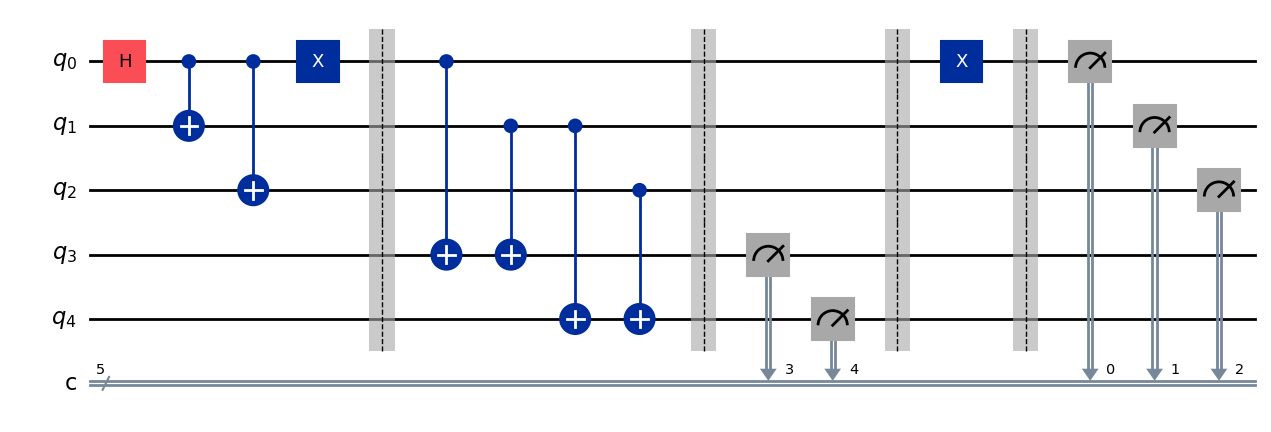

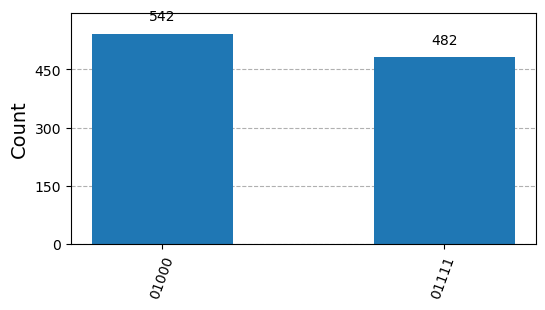

In [48]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)       
qc.cx(0, 1)   
qc.cx(0, 2)
qc.x(0)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
qc.measure(3, 3) 
qc.measure(4, 4) 
qc.barrier()
qc.x(0)
qc.barrier() 

#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Raw Counts: {'11111': 528, '11000': 496}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 11 -> Syndrome Eigenvalues: [-1, -1], Count: 528
Bits: 00 -> Syndrome Eigenvalues: [1, 1], Count: 496


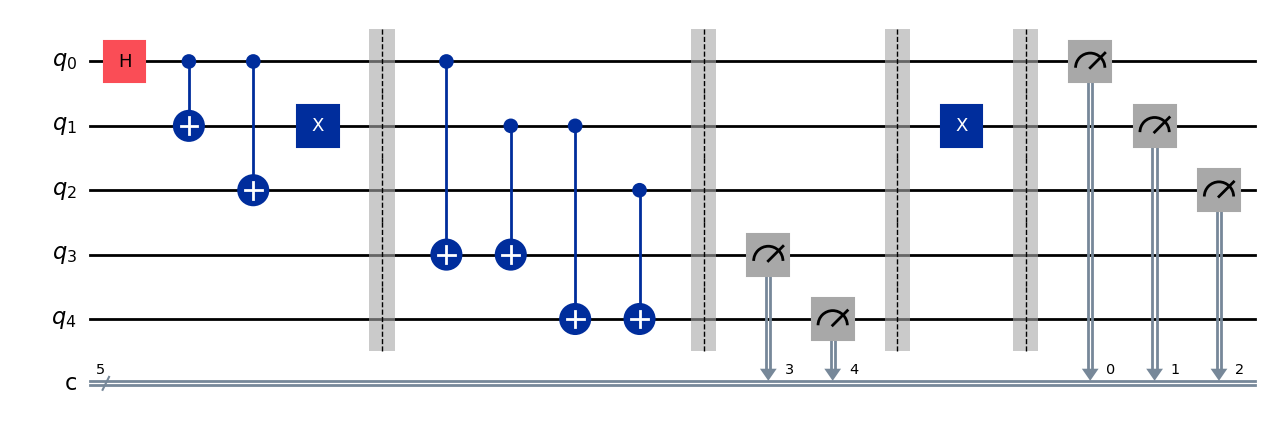

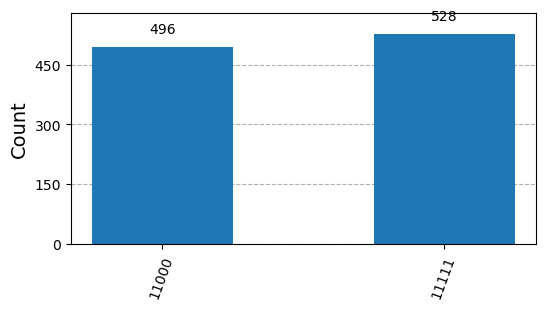

In [49]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)       
qc.cx(0, 1)   
qc.cx(0, 2)
qc.x(1)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
qc.measure(3, 3) 
qc.measure(4, 4) 
qc.barrier()
qc.x(1)
qc.barrier() 

#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Raw Counts: {'10111': 508, '10000': 516}
Syndrome Measurements (Z1Z2, Z2Z3):
Bits: 11 -> Syndrome Eigenvalues: [-1, -1], Count: 508
Bits: 00 -> Syndrome Eigenvalues: [1, 1], Count: 516


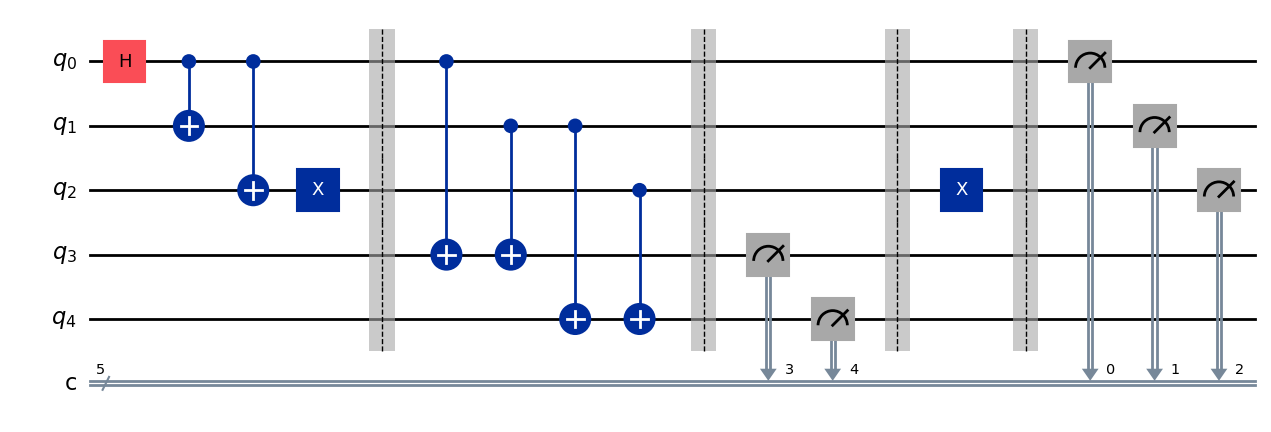

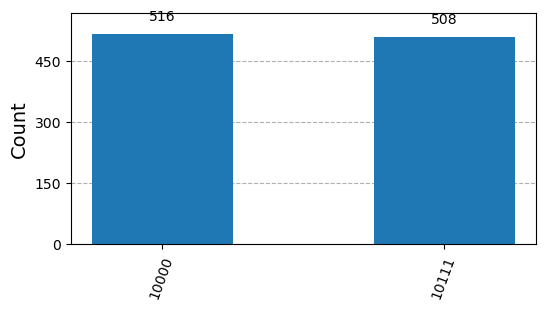

In [50]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# 3 data qubits + 2 ancilla, 5 classical bits
qc = QuantumCircuit(5, 5)

#Encode logical qubit
qc.h(0)       
qc.cx(0, 1)   
qc.cx(0, 2)
qc.x(2)
qc.barrier()

#Syndrome measurement Z1Z2 and Z2Z3
qc.cx(0, 3)
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(2, 4)
qc.barrier()
qc.measure(3, 3) 
qc.measure(4, 4) 
qc.barrier()
qc.x(2)
qc.barrier() 

#Measure data qubits
qc.measure(0, 0)
qc.measure(1, 1)
qc.measure(2, 2)

#Run on AerSimulator
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
result = simulator.run(compiled_qc, shots=1024).result()

#counts
counts = result.get_counts()
print("Raw Counts:", counts)

#Print syndrome eigenvalues 
print("Syndrome Measurements (Z1Z2, Z2Z3):")
for bitstring in counts:
    ancilla_bits = bitstring[-2:]  
    # Convert 0 -> +1, 1 -> -1
    eigenvalues = [1 if b=='0' else -1 for b in ancilla_bits]
    print(f"Bits: {ancilla_bits} -> Syndrome Eigenvalues: {eigenvalues}, Count: {counts[bitstring]}")
    

# Circuit 
qc.draw('mpl')
plt.show()
display(qc.draw(output='mpl'))

#Plot histogram
fig, ax = plt.subplots(figsize=(6,3))
plot_histogram(counts, ax=ax)
plt.show()

Crucially, the state of the top three qubits does not collapse in any of the cases, which allows us to correct a bit-flip error if one has occurred — by simply applying the same bit-flip again with an 
X gate. The following table summarizes the states we obtain from at most one bit-flip, the measurement outcomes (which are called the syndrome in the context of error correction), and the correction needed to get back to the original encoding.

In [ ]:
```
| State                        | Syndrome | Correction         |
|-------------------------------|---------|------------------|
| α|000⟩ + β|111⟩               | 00      | I ⊗ I ⊗ I       |
| α|001⟩ + β|110⟩               | 01      | I ⊗ I ⊗ X       |
| α|010⟩ + β|101⟩               | 11      | I ⊗ X ⊗ I       |
| α|100⟩ + β|011⟩               | 10      | X ⊗ I ⊗ I       |
```

Once again, we're only considering the possibility that at most one bit-flip occurred. This wouldn't work correctly if two or three bit-flips occurred, and we also haven't considered other possible errors besides bit-flips.